In [1]:
from google.colab import files

uploaded = files.upload()


Saving online_course_recommendation_v2.xlsx to online_course_recommendation_v2 (10).xlsx


In [2]:
import pandas as pd

df = pd.read_excel('online_course_recommendation_v2.xlsx')
df


,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken
0,15796,9366,Python for Beginners,Emma Harris,39.1,Yes,Beginner,5.0,21600,317.50,0.797,Yes,17.60,4
1,861,1928,Cybersecurity for Professionals,Alexander Young,36.3,Yes,Beginner,4.3,15379,40.99,0.770,Yes,28.97,9
2,38159,9541,DevOps and Continuous Deployment,Dr. Mia Walker,13.4,Yes,Beginner,3.9,6431,380.81,0.772,Yes,52.44,4
3,44733,3708,Project Management Fundamentals,Benjamin Lewis,58.3,Yes,Beginner,3.1,48245,342.80,0.969,No,22.29,6
4,11285,3361,Ethical Hacking Masterclass,Daniel White,30.8,Yes,Beginner,2.8,34556,381.01,0.555,Yes,22.01,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,10647,5466,Graphic Design with Canva,Emma Harris,17.3,Yes,Beginner,3.9,49101,485.34,0.838,Yes,16.35,3
99996,13800,2623,Stock Market and Trading Strategies,Dr. John Smith,68.4,Yes,Beginner,3.5,35107,162.80,0.922,Yes,41.94,7
99997,47131,1556,Networking and System Administration,Dr. John Smith,73.8,Yes,Beginner,4.3,12146,24.02,0.990,Yes,15.87,5
99998,49654,6001,Graphic Design with Canva,Daniel White,30.3,Yes,Beginner,3.5,9933,402.24,0.630,Yes,21.05,4


In [3]:
print(df.shape)


(100000, 14)


In [4]:
df.info()
df.dtypes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   user_id                   100000 non-null  int64  
 1   course_id                 100000 non-null  int64  
 2   course_name               100000 non-null  object 
 3   instructor                100000 non-null  object 
 4   course_duration_hours     100000 non-null  float64
 5   certification_offered     100000 non-null  object 
 6   difficulty_level          100000 non-null  object 
 7   rating                    100000 non-null  float64
 8   enrollment_numbers        100000 non-null  int64  
 9   course_price              100000 non-null  float64
 10  feedback_score            100000 non-null  float64
 11  study_material_available  100000 non-null  object 
 12  time_spent_hours          100000 non-null  float64
 13  previous_courses_taken    100000 non-null  in

,0
user_id,int64
course_id,int64
course_name,object
instructor,object
course_duration_hours,float64
certification_offered,object
difficulty_level,object
rating,float64
enrollment_numbers,int64
course_price,float64


In [5]:
df.isnull().sum()
df.isnull().mean() * 100   # % missing


,0
user_id,0.0
course_id,0.0
course_name,0.0
instructor,0.0
course_duration_hours,0.0
certification_offered,0.0
difficulty_level,0.0
rating,0.0
enrollment_numbers,0.0
course_price,0.0


In [6]:
# Convert columns correctly
df['user_id'] = df['user_id'].astype(str)
df['course_id'] = df['course_id'].astype(str)

cat_cols = ['course_name','instructor','certification_offered',
            'difficulty_level','study_material_available']

for col in cat_cols:
    df[col] = df[col].astype(str)


In [7]:
df.dtypes

,0
user_id,object
course_id,object
course_name,object
instructor,object
course_duration_hours,float64
certification_offered,object
difficulty_level,object
rating,float64
enrollment_numbers,int64
course_price,float64


In [8]:
df.duplicated().sum()

# user–course duplicates (important for recommender system)
df.duplicated(subset=['user_id','course_id']).sum()


np.int64(5)

In [9]:
df = df.drop_duplicates(subset=['user_id', 'course_id'], keep='first')


In [10]:
print(df.shape)

(99995, 14)


In [11]:
num_cols = df.select_dtypes(include=['int','float']).columns

df[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
course_duration_hours,99995.0,52.383009,27.423331,5.000,28.600,52.40,76.100,100.00
rating,99995.0,3.959839,0.729951,1.000,3.500,4.00,4.500,5.00
enrollment_numbers,99995.0,25052.346387,14388.022889,50.000,12583.500,25056.00,37521.000,49999.00
course_price,99995.0,261.078098,139.014508,20.000,140.100,262.33,381.710,500.00
feedback_score,99995.0,0.746870,0.143681,0.092,0.649,0.75,0.851,1.00
time_spent_hours,99995.0,20.690852,13.669291,1.000,9.900,19.92,30.080,84.15
previous_courses_taken,99995.0,4.992590,2.237256,0.000,3.000,5.00,6.000,19.00


In [12]:

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print("\nColumn:", col)
    print(df[col].value_counts().head(10))



Column: user_id
user_id
37381    11
646      10
48000     9
10560     9
37998     9
26026     9
6554      9
369       9
11094     9
47554     9
Name: count, dtype: int64

Column: course_id
course_id
1139    23
3658    23
4335    23
346     22
2501    21
7761    21
1153    21
8382    20
2504    20
2177    20
Name: count, dtype: int64

Column: course_name
course_name
Networking and System Administration    5107
Cybersecurity for Professionals         5078
Ethical Hacking Masterclass             5062
Advanced Machine Learning               5062
Graphic Design with Canva               5057
DevOps and Continuous Deployment        5037
Public Speaking Mastery                 5028
Mobile App Development with Swift       5024
Stock Market and Trading Strategies     5021
Data Visualization with Tableau         5010
Name: count, dtype: int64

Column: instructor
instructor
Jessica Martinez       5092
Sophia Anderson        5089
David Wilson           5083
Emma Harris            5065
Isabella Sco

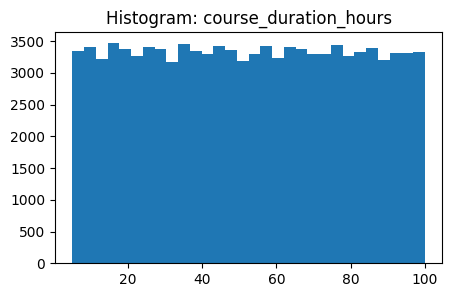

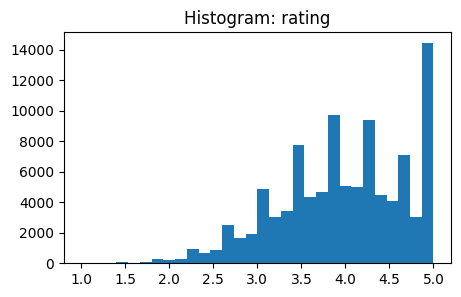

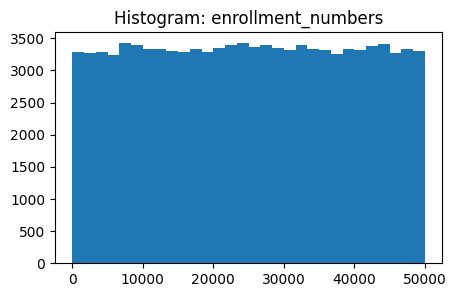

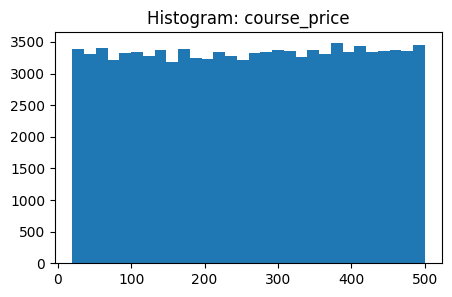

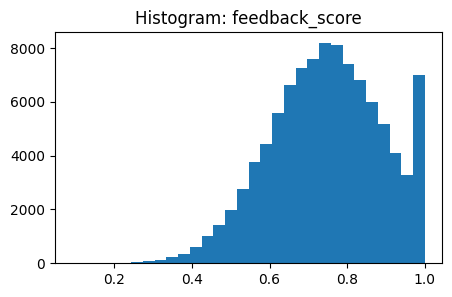

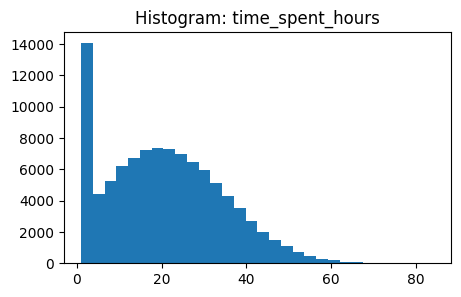

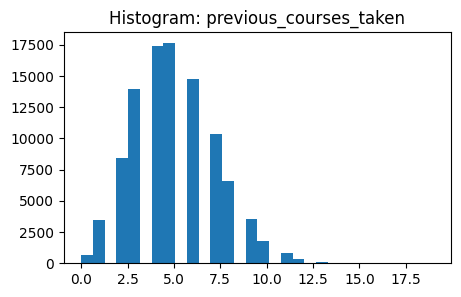

In [13]:
import matplotlib.pyplot as plt

for col in num_cols:
    plt.figure(figsize=(5,3))
    plt.hist(df[col], bins=30)
    plt.title(f"Histogram: {col}")
    plt.show()


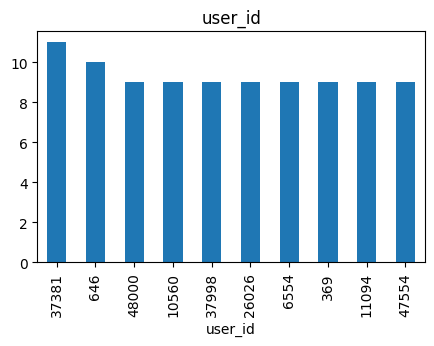

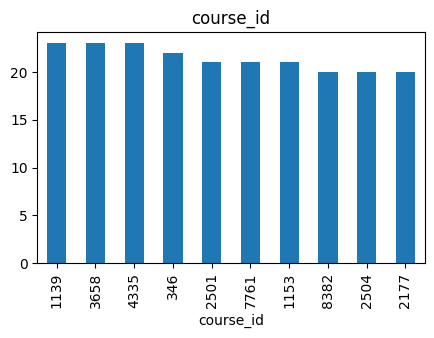

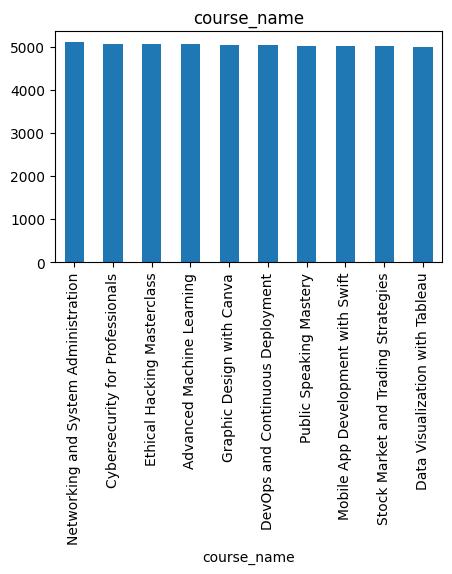

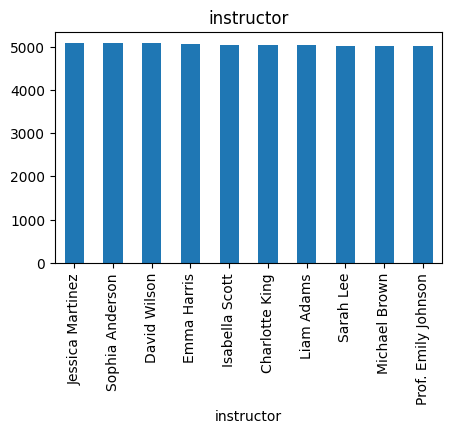

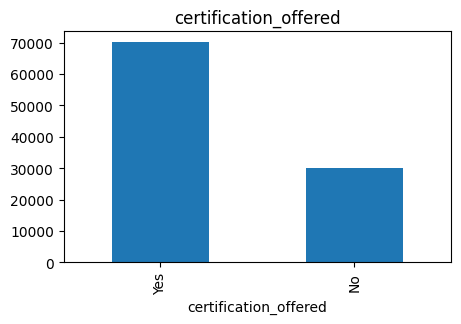

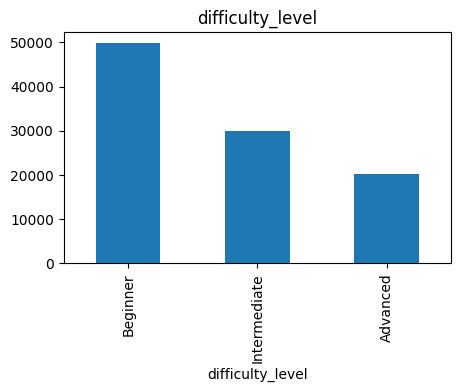

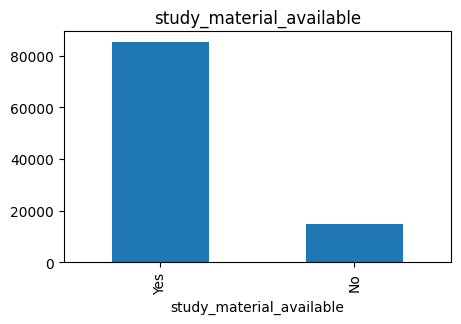

In [14]:
for col in cat_cols:
    plt.figure(figsize=(5,3))
    df[col].value_counts().head(10).plot(kind='bar')
    plt.title(col)
    plt.show()


In [15]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[num_cols] < (Q1 - 1.5 * IQR)) |
            (df[num_cols] > (Q3 + 1.5 * IQR)))

outliers.sum()


,0
course_duration_hours,0
rating,529
enrollment_numbers,0
course_price,0
feedback_score,377
time_spent_hours,342
previous_courses_taken,1373


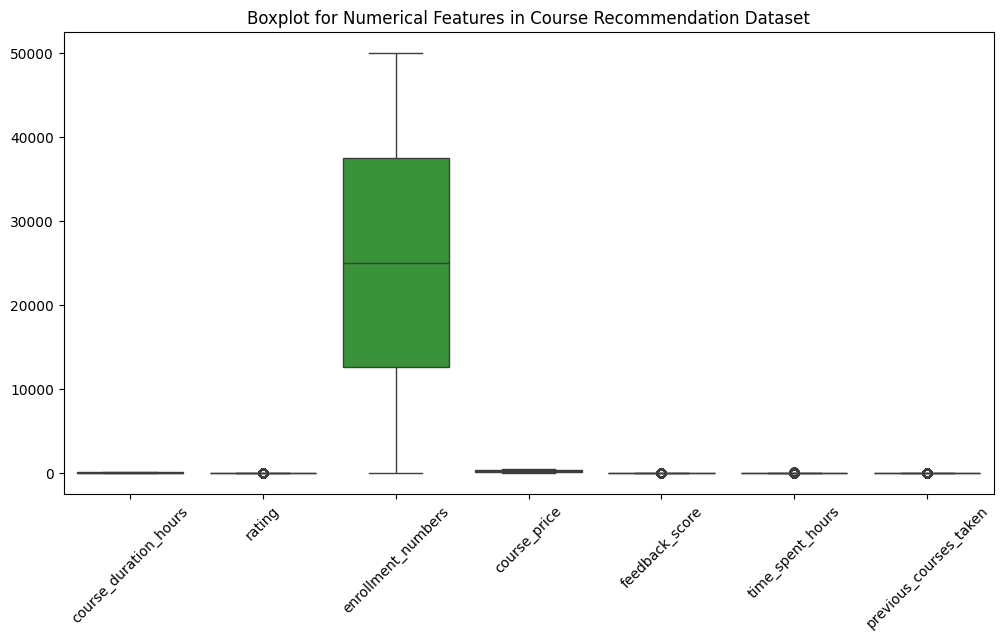

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(data=df[num_cols])
plt.title("Boxplot for Numerical Features in Course Recommendation Dataset")
plt.xticks(rotation=45)
plt.show()


In [17]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)


/tmp/ipython-input-2855208803.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].clip(lower, upper)
/tmp/ipython-input-2855208803.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].clip(lower, upper)
/tmp/ipython-input-2855208803.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_g

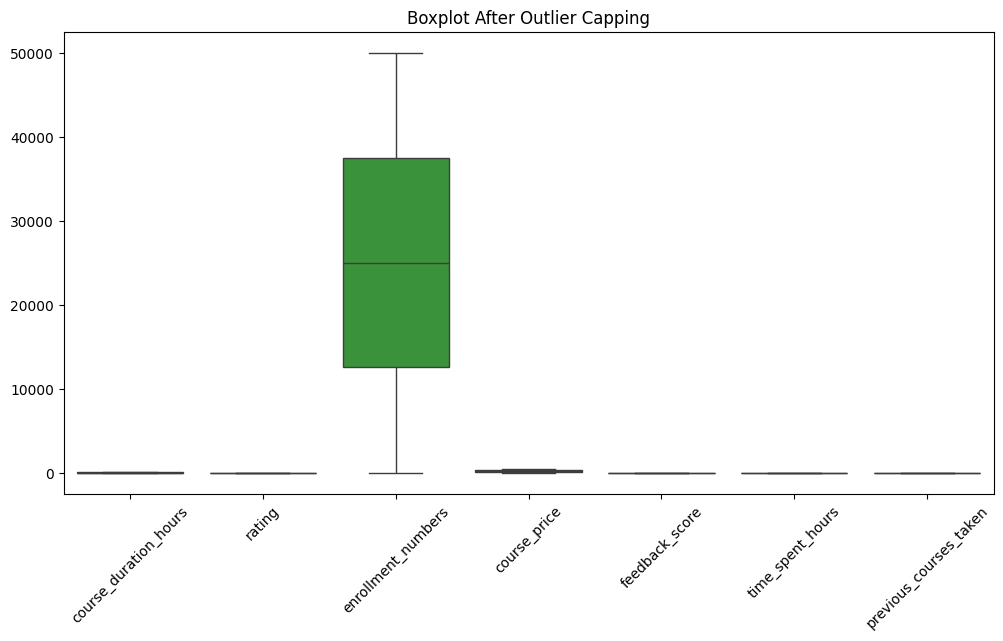

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(data=df[num_cols])
plt.title("Boxplot After Outlier Capping")
plt.xticks(rotation=45)
plt.show()


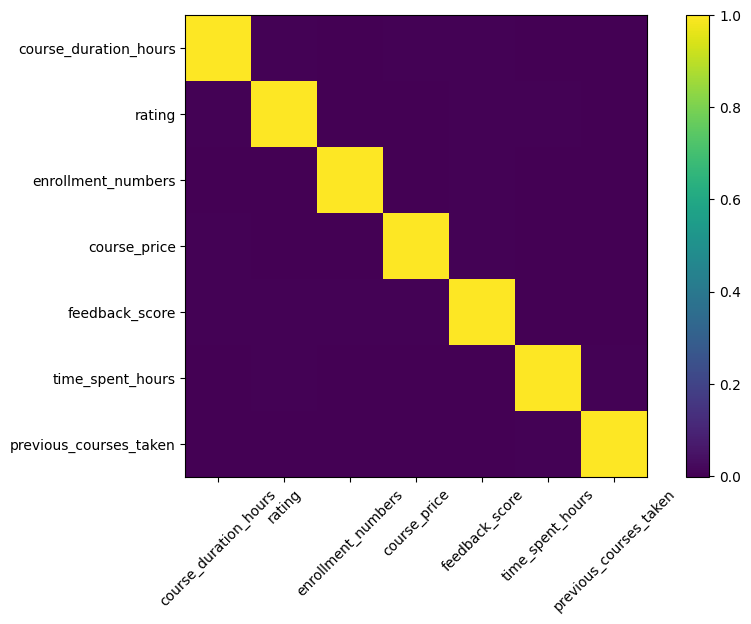

In [19]:
plt.figure(figsize=(10,6))
plt.imshow(df[num_cols].corr(), cmap='viridis')
plt.colorbar()
plt.xticks(range(len(num_cols)), num_cols, rotation=45)
plt.yticks(range(len(num_cols)), num_cols)
plt.show()


Important EDA for Recommendation **System**

In [20]:
df.groupby('course_name')['user_id'].count().sort_values(ascending=False).head(10)


,user_id
course_name,
Networking and System Administration,5107
Cybersecurity for Professionals,5078
Advanced Machine Learning,5062
Ethical Hacking Masterclass,5062
Graphic Design with Canva,5057
DevOps and Continuous Deployment,5037
Public Speaking Mastery,5028
Mobile App Development with Swift,5024
Stock Market and Trading Strategies,5021


In [21]:

df.groupby('course_name')['rating'].mean().sort_values(ascending=False).head(10)


,rating
course_name,
Python for Beginners,3.979598
Cloud Computing Essentials,3.975660
Photography and Video Editing,3.971886
Advanced Machine Learning,3.970427
Personal Finance and Wealth Building,3.965964
Fitness and Nutrition Coaching,3.965654
Project Management Fundamentals,3.964277
Ethical Hacking Masterclass,3.962031
Mobile App Development with Swift,3.961863


In [22]:
df.groupby('course_name')['enrollment_numbers'].mean().sort_values(ascending=False).head(10)


,enrollment_numbers
course_name,
Graphic Design with Canva,25356.299980
Fitness and Nutrition Coaching,25334.165205
Blockchain and Decentralized Applications,25313.235519
DevOps and Continuous Deployment,25241.720469
Cloud Computing Essentials,25154.256801
AI for Business Leaders,25131.299581
Ethical Hacking Masterclass,25094.782102
Photography and Video Editing,25077.173608
Cybersecurity for Professionals,25056.595116


In [23]:
df.groupby('user_id')['previous_courses_taken'].sum().sort_values(ascending=False).head(10)


,previous_courses_taken
user_id,
37381,65.0
48000,61.5
47554,60.0
38420,53.5
11094,52.0
646,52.0
26141,51.5
369,51.0
49968,50.0


In [24]:
df

,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken
0,15796,9366,Python for Beginners,Emma Harris,39.1,Yes,Beginner,5.0,21600,317.50,0.797,Yes,17.60,4.0
1,861,1928,Cybersecurity for Professionals,Alexander Young,36.3,Yes,Beginner,4.3,15379,40.99,0.770,Yes,28.97,9.0
2,38159,9541,DevOps and Continuous Deployment,Dr. Mia Walker,13.4,Yes,Beginner,3.9,6431,380.81,0.772,Yes,52.44,4.0
3,44733,3708,Project Management Fundamentals,Benjamin Lewis,58.3,Yes,Beginner,3.1,48245,342.80,0.969,No,22.29,6.0
4,11285,3361,Ethical Hacking Masterclass,Daniel White,30.8,Yes,Beginner,2.8,34556,381.01,0.555,Yes,22.01,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,10647,5466,Graphic Design with Canva,Emma Harris,17.3,Yes,Beginner,3.9,49101,485.34,0.838,Yes,16.35,3.0
99996,13800,2623,Stock Market and Trading Strategies,Dr. John Smith,68.4,Yes,Beginner,3.5,35107,162.80,0.922,Yes,41.94,7.0
99997,47131,1556,Networking and System Administration,Dr. John Smith,73.8,Yes,Beginner,4.3,12146,24.02,0.990,Yes,15.87,5.0
99998,49654,6001,Graphic Design with Canva,Daniel White,30.3,Yes,Beginner,3.5,9933,402.24,0.630,Yes,21.05,4.0


In [25]:


from sklearn.preprocessing import MinMaxScaler

# 1. Make a copy so original df remains safe
df_scaled = df.copy()

# 2. List of columns to scale
scale_cols = ['rating','course_price','feedback_score','time_spent_hours']

# 3. Apply MinMax scaling only to df_scaled
scaler = MinMaxScaler()
df_scaled[scale_cols] = scaler.fit_transform(df_scaled[scale_cols])


In [26]:
df

,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken
0,15796,9366,Python for Beginners,Emma Harris,39.1,Yes,Beginner,5.0,21600,317.50,0.797,Yes,17.60,4.0
1,861,1928,Cybersecurity for Professionals,Alexander Young,36.3,Yes,Beginner,4.3,15379,40.99,0.770,Yes,28.97,9.0
2,38159,9541,DevOps and Continuous Deployment,Dr. Mia Walker,13.4,Yes,Beginner,3.9,6431,380.81,0.772,Yes,52.44,4.0
3,44733,3708,Project Management Fundamentals,Benjamin Lewis,58.3,Yes,Beginner,3.1,48245,342.80,0.969,No,22.29,6.0
4,11285,3361,Ethical Hacking Masterclass,Daniel White,30.8,Yes,Beginner,2.8,34556,381.01,0.555,Yes,22.01,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,10647,5466,Graphic Design with Canva,Emma Harris,17.3,Yes,Beginner,3.9,49101,485.34,0.838,Yes,16.35,3.0
99996,13800,2623,Stock Market and Trading Strategies,Dr. John Smith,68.4,Yes,Beginner,3.5,35107,162.80,0.922,Yes,41.94,7.0
99997,47131,1556,Networking and System Administration,Dr. John Smith,73.8,Yes,Beginner,4.3,12146,24.02,0.990,Yes,15.87,5.0
99998,49654,6001,Graphic Design with Canva,Daniel White,30.3,Yes,Beginner,3.5,9933,402.24,0.630,Yes,21.05,4.0


In [27]:
df_scaled

,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken
0,15796,9366,Python for Beginners,Emma Harris,39.1,Yes,Beginner,1.000000,21600,0.619792,0.689602,Yes,0.279697,4.0
1,861,1928,Cybersecurity for Professionals,Alexander Young,36.3,Yes,Beginner,0.766667,15379,0.043729,0.648318,Yes,0.471272,9.0
2,38159,9541,DevOps and Continuous Deployment,Dr. Mia Walker,13.4,Yes,Beginner,0.633333,6431,0.751688,0.651376,Yes,0.866723,4.0
3,44733,3708,Project Management Fundamentals,Benjamin Lewis,58.3,Yes,Beginner,0.366667,48245,0.672500,0.952599,No,0.358719,6.0
4,11285,3361,Ethical Hacking Masterclass,Daniel White,30.8,Yes,Beginner,0.266667,34556,0.752104,0.319572,Yes,0.354002,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,10647,5466,Graphic Design with Canva,Emma Harris,17.3,Yes,Beginner,0.633333,49101,0.969458,0.752294,Yes,0.258635,3.0
99996,13800,2623,Stock Market and Trading Strategies,Dr. John Smith,68.4,Yes,Beginner,0.500000,35107,0.297500,0.880734,Yes,0.689806,7.0
99997,47131,1556,Networking and System Administration,Dr. John Smith,73.8,Yes,Beginner,0.766667,12146,0.008375,0.984709,Yes,0.250548,5.0
99998,49654,6001,Graphic Design with Canva,Daniel White,30.3,Yes,Beginner,0.500000,9933,0.796333,0.434251,Yes,0.337826,4.0


In [28]:
""" Feature Engineering (Content + User Interaction)

Create text features for content-based filtering

Create user–course matrix for collaborative filtering

Normalize ratings

prepare final hybrid score """

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
import numpy as np

# -----------------------------
# 1. DATA (df_scaled already created by us)
# -----------------------------
df_hybrid = df_scaled.copy()

# Combine text + categorical data into one string for TF-IDF
df_hybrid["combined_features"] = (
    df_hybrid["course_name"].astype(str) + " " +
    df_hybrid["instructor"].astype(str) + " " +
    df_hybrid["difficulty_level"].astype(str) + " " +
    df_hybrid["certification_offered"].astype(str) + " " +
    df_hybrid["study_material_available"].astype(str)
)



In [29]:
# -----------------------------
# 2. CONTENT-BASED FILTERING
# -----------------------------
tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(df_hybrid["combined_features"])

# Function to get content-based recommendations
def recommend_content(course_id, top_n=5):
    idx = df_hybrid[df_hybrid["course_id"] == course_id].index[0]

    # Compute similarity of this course with all courses (1 × N, not N × N)
    sim = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()

    # Get best matches
    top_indices = sim.argsort()[::-1][1:top_n+1]

    return df_hybrid.iloc[top_indices][["course_id","course_name"]]


In [30]:
# -----------------------------
# 3. COLLABORATIVE FILTERING (User–Course Matrix)
# -----------------------------
pivot = df_hybrid.pivot_table(index='user_id',
                              columns='course_id',
                              values='rating').fillna(0)

model_knn = NearestNeighbors(metric='cosine', algorithm='brute')
model_knn.fit(pivot)

# Function to get collaborative filtering recommendations
def recommend_collab(user_id, top_n=5):
    user_vector = pivot.loc[user_id].values.reshape(1, -1)
    distances, indices = model_knn.kneighbors(user_vector, n_neighbors=6)

    similar_users = pivot.index[indices.flatten()][1:]

    # Weighted average rating of similar users
    user_mean = pivot.loc[similar_users].mean().sort_values(ascending=False)

    recommended_courses = user_mean.head(top_n).index

    return df_hybrid[df_hybrid["course_id"].isin(recommended_courses)][
        ["course_id","course_name"]
    ]



In [31]:
# -----------------------------
# 4. HYBRID RECOMMENDATION
# -----------------------------
def hybrid_recommend(user_id, course_id, top_n=5, w1=0.5, w2=0.5):
    # content-based
    content_df = recommend_content(course_id, top_n=20)

    # collaborative filtering
    collab_df = recommend_collab(user_id, top_n=20)

    # Assign scores (1 decreasing)
    content_df["content_score"] = np.linspace(1, 0.1, len(content_df))
    collab_df["collab_score"] = np.linspace(1, 0.1, len(collab_df))

    # Combine
    combined = pd.merge(content_df, collab_df,
                        on=["course_id","course_name"],
                        how="outer")

    # Fill missing values
    combined["content_score"] = combined["content_score"].fillna(0)
    combined["collab_score"] = combined["collab_score"].fillna(0)

    # Weighted Hybrid Score
    combined["hybrid_score"] = (
        w1 * combined["content_score"] +
        w2 * combined["collab_score"]
    )

    # Final result
    return combined.sort_values("hybrid_score", ascending=False).head(top_n)




In [32]:
# -----------------------------
# 5. TESTING THE HYBRID MODEL
# -----------------------------
print("Content-based recommendations:")
print(recommend_content(course_id="9366"))    # ★ change course_id



Content-based recommendations:
      course_id           course_name
46573      1829  Python for Beginners
30289      4855  Python for Beginners
83160      4956  Python for Beginners
46507      3000  Python for Beginners
36504      1843  Python for Beginners


In [33]:
df_hybrid["course_id"].head()


,course_id
0,9366
1,1928
2,9541
3,3708
4,3361


In [34]:
print("Collaborative recommendations:")
print(recommend_collab(user_id="15796"))         # ★ change user_id



Collaborative recommendations:


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


      course_id                                course_name
0          9366                       Python for Beginners
7350       9366           DevOps and Continuous Deployment
8725       7727             Fitness and Nutrition Coaching
10129      9366              Photography and Video Editing
10756      9919                       Python for Beginners
11377      4206       Networking and System Administration
12280      8801                    AI for Business Leaders
18756      9366                  Advanced Machine Learning
20445      9919                  Graphic Design with Canva
21315      9919            Project Management Fundamentals
22353      7727       Personal Finance and Wealth Building
24686      8801       Personal Finance and Wealth Building
27027      8801            Data Visualization with Tableau
27361      7727  Blockchain and Decentralized Applications
28062      7727          Fundamentals of Digital Marketing
28205      4206                       Python for Beginne

In [35]:
print("Hybrid final recommendations:")
print(hybrid_recommend(user_id="15796", course_id="9366"))                  # write 9366 as "9366" as data type is str


Hybrid final recommendations:


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


    course_id                        course_name  content_score  collab_score  \
58       6993               Python for Beginners       0.621053      0.656522   
2        1829               Python for Beginners       1.000000      0.000000   
214      9366               Python for Beginners       0.000000      1.000000   
62       6994  Fundamentals of Digital Marketing       0.000000      0.995652   
47       6993          Advanced Machine Learning       0.000000      0.991304   

     hybrid_score  
58       0.638787  
2        0.500000  
214      0.500000  
62       0.497826  
47       0.495652  


In [ ]:
###Step 1 — Train-Test Split for Collaborative Filtering

In [ ]:
###We hide some ratings and test if the model predicts them correctly.

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_squared_error
import numpy as np

# -----------------------------------------------
# 1. TRAIN-TEST SPLIT
# -----------------------------------------------
train_df, test_df = train_test_split(
    df_hybrid[['user_id', 'course_id', 'rating']],
    test_size=0.2,
    random_state=42
)

# -----------------------------------------------
# 2. FILTER USERS WITH MINIMUM 5 INTERACTIONS
# -----------------------------------------------
user_counts = train_df['user_id'].value_counts()
filtered_users = user_counts[user_counts >= 5].index

train_df_small = train_df[train_df['user_id'].isin(filtered_users)]

# -----------------------------------------------
# 3. CREATE PIVOT TABLE FROM FILTERED TRAIN DATA
# -----------------------------------------------
train_pivot = train_df_small.pivot_table(
    index='user_id',
    columns='course_id',
    values='rating'
).fillna(0)

print("Pivot shape:", train_pivot.shape)   # (reduced_users × courses)

# -----------------------------------------------
# 4. FIT KNN MODEL
# -----------------------------------------------
model_knn = NearestNeighbors(
    metric='cosine',
    algorithm='brute',
    n_jobs=-1     # faster
)

model_knn.fit(train_pivot)

print("KNN model trained successfully!")


Pivot shape: (1191, 4709)
KNN model trained successfully!


In [ ]:
###Predict a Rating (KNN CF)

In [37]:
def predict_rating(user_id, course_id):
    # If user or item not present
    if user_id not in train_pivot.index or course_id not in train_pivot.columns:
        return np.nan

    user_vector = train_pivot.loc[user_id].values.reshape(1, -1)
    distances, indices = model_knn.kneighbors(user_vector, n_neighbors=6)

    similar_users = train_pivot.index[indices.flatten()][1:]

    # Ratings from similar users
    ratings = train_pivot.loc[similar_users, course_id]

    # If all ratings zero → no info
    if ratings.sum() == 0:
        return np.nan

    return ratings.mean()


In [ ]:
###RMSE Evaluation

In [38]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


y_true = []
y_pred = []

for _, row in test_df.iterrows():
    r = predict_rating(row.user_id, row.course_id)
    if not np.isnan(r):
        y_true.append(row.rating)
        y_pred.append(r)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print("RMSE:", rmse)


RMSE: 0.6633835826863502


In [ ]:
###Precision@K & Recall@K

In [ ]:
###We check how many recommended courses belong to the user’s actual test-rated items.

In [39]:
def precision_recall_at_k(user_id, k=5):
    if user_id not in train_pivot.index:
        return None, None

    # Get vector for this user (from TRAIN pivot)
    user_vector = train_pivot.loc[user_id].values.reshape(1, -1)

    # KNN → Find similar users
    distances, indices = model_knn.kneighbors(user_vector, n_neighbors=6)

    similar_users = train_pivot.index[indices.flatten()][1:]

    # Recommend top courses
    user_mean = train_pivot.loc[similar_users].mean().sort_values(ascending=False)
    recommended_courses = user_mean.head(k).index

    # -------------------------------
    # TRUE items from TEST set only
    # -------------------------------
    true_items = test_df[test_df['user_id'] == user_id]['course_id'].unique()

    if len(true_items) == 0:
        return None, None

    # Convert recommended to set
    recommended_set = set(recommended_courses)
    true_set = set(true_items)

    # Precision = relevant recommended / total recommended
    precision = len(recommended_set & true_set) / len(recommended_set)

    # Recall = relevant recommended / relevant items
    recall = len(recommended_set & true_set) / len(true_set)

    return precision, recall


In [ ]:
###Evaluate for all users:

In [40]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


precisions = []
recalls = []

for user in test_df['user_id'].unique():
    p, r = precision_recall_at_k(user, k=5)
    if p is not None:
        precisions.append(p)
        recalls.append(r)

print("Precision@5:", np.mean(precisions))
print("Recall@5:", np.mean(recalls))


Precision@5: 0.0005347593582887701
Recall@5: 0.00089126559714795


In [ ]:
###NDCG@K (Ranking Quality)

In [ ]:
###Measures if the most relevant items appear higher in ranking.

In [41]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)



import numpy as np
def ndcg_k(user_id, k=5):

    # If user missing in training, return 0
    if user_id not in train_pivot.index:
        return 0

    # ---- RECOMMENDATIONS ----
    user_vector = train_pivot.loc[user_id].values.reshape(1, -1)
    distances, indices = model_knn.kneighbors(user_vector, n_neighbors=6)

    similar_users = train_pivot.index[indices.flatten()][1:]

    user_mean = train_pivot.loc[similar_users].mean().sort_values(ascending=False)
    recommended_courses = list(user_mean.head(k).index)

    # ---- TRUE LABELS ----
    true_items = test_df[test_df["user_id"] == user_id]["course_id"].unique()

    if len(true_items) == 0:
        return 0   # no ground truth = score 0

    # ---- DCG ----
    relevance = [1 if item in true_items else 0 for item in recommended_courses]
    dcg = sum([rel / np.log2(i + 2) for i, rel in enumerate(relevance)])

    # ---- IDCG ----
    ideal_relevance = sorted(relevance, reverse=True)
    idcg = sum([rel / np.log2(i + 2) for i, rel in enumerate(ideal_relevance)])

    if idcg == 0:
        return 0

    return dcg / idcg



In [ ]:
###Evaluate:

In [42]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)



ndcgs = []
for user in test_df['user_id'].unique():
    ndcgs.append(ndcg_k(user, k=5))

print("NDCG@5:", np.mean(ndcgs))


NDCG@5: 2.3427166913010453e-05


In [ ]:

###Step 6 — Coverage (How many unique courses we recommend?)

In [43]:
def coverage(k=5):

    recommended_items = set()

    for user in train_pivot.index:
        user_vector = train_pivot.loc[user].values.reshape(1, -1)

        distances, indices = model_knn.kneighbors(user_vector, n_neighbors=6)

        similar_users = train_pivot.index[indices.flatten()][1:]
        user_mean = train_pivot.loc[similar_users].mean().sort_values(ascending=False)

        top_items = user_mean.head(k).index
        recommended_items.update(top_items)

    return len(recommended_items) / train_pivot.shape[1]
print("Coverage:", coverage(k=5))


Coverage: 0.33340411977065193


In [44]:
# ================================================
# FAST HYBRID MODEL METRICS
# Precompute, cache & reduce redundant processing
# ================================================

import numpy as np
import pandas as pd

# ---------------------------
# 1. Precompute Seed Course for Each User
# ---------------------------
user_seed = {}

for user in df_hybrid["user_id"].unique():
    user_courses = df_hybrid[df_hybrid["user_id"] == user]["course_id"]
    if len(user_courses) > 0:
        user_seed[user] = user_courses.sample(1).iloc[0]



In [45]:
# ---------------------------
# 2. Cache CF & Content Results for Each User
# ---------------------------

cf_cache = {}
cb_cache = {}

def get_cf(user):
    if user not in cf_cache:
        try:
            temp = recommend_collab(user, top_n=20)
            temp["collab_score"] = np.linspace(1, 0.1, len(temp))
            cf_cache[user] = temp
        except:
            cf_cache[user] = pd.DataFrame(columns=["course_id", "collab_score"])
    return cf_cache[user]


def get_cb(course_id):
    if course_id not in cb_cache:
        try:
            temp = recommend_content(course_id, top_n=20)
            temp["content_score"] = np.linspace(1, 0.1, len(temp))
            cb_cache[course_id] = temp
        except:
            cb_cache[course_id] = pd.DataFrame(columns=["course_id", "content_score"])
    return cb_cache[course_id]




In [46]:
# ---------------------------
# 3. Hybrid Recommender (Fast)
# ---------------------------

def fast_hybrid(user_id, seed_course, k=5, w1=0.5, w2=0.5):

    cb_df = get_cb(seed_course)
    cf_df = get_cf(user_id)

    merged = pd.merge(cb_df, cf_df, on="course_id", how="outer")

    merged["content_score"] = merged["content_score"].fillna(0)
    merged["collab_score"] = merged["collab_score"].fillna(0)

    merged["hybrid_score"] = w1 * merged["content_score"] + w2 * merged["collab_score"]
    merged = merged.sort_values("hybrid_score", ascending=False)

    return merged["course_id"].head(k).tolist()




In [47]:
# ---------------------------
# 4. Precision, Recall, NDCG
# ---------------------------

def hybrid_precision_recall(user_id, k=5):
    true_items = test_df[test_df["user_id"] == user_id]["course_id"].unique()
    if len(true_items) == 0:
        return None, None

    if user_id not in user_seed:
        return None, None

    seed_course = user_seed[user_id]

    predicted = fast_hybrid(user_id, seed_course, k=k)

    rec_set = set(predicted)
    true_set = set(true_items)

    precision = len(rec_set & true_set) / k
    recall = len(rec_set & true_set) / len(true_set)

    return precision, recall


def hybrid_ndcg(user_id, k=5):
    true_items = test_df[test_df["user_id"] == user_id]["course_id"].unique()
    if len(true_items) == 0:
        return 0

    seed_course = user_seed[user_id]

    predicted = fast_hybrid(user_id, seed_course, k=k)

    relevance = [1 if item in true_items else 0 for item in predicted]

    dcg = sum([rel / np.log2(i + 2) for i, rel in enumerate(relevance)])
    ideal_rel = sorted(relevance, reverse=True)
    idcg = sum([rel / np.log2(i + 2) for i, rel in enumerate(ideal_rel)])

    return dcg / idcg if idcg != 0 else 0




In [48]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


# ---------------------------
# 5. FINAL METRICS (10x Faster)
# ---------------------------

precisions = []
recalls = []
ndcgs = []

for user in test_df["user_id"].unique():
    p, r = hybrid_precision_recall(user, k=5)
    if p is not None:
        precisions.append(p)
        recalls.append(r)
        ndcgs.append(hybrid_ndcg(user, k=5))

print("\n========== FAST HYBRID MODEL METRICS ==========\n")
print("Hybrid Precision@5:", np.mean(precisions))
print("Hybrid Recall@5:", np.mean(recalls))
print("Hybrid NDCG@5:", np.mean(ndcgs))
print("===============================================\n")




Streaming output truncated to the last 5000 lines.
/tmp/ipython-input-1126370580.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged["collab_score"] = merged["collab_score"].fillna(0)
/tmp/ipython-input-1126370580.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged["collab_score"] = merged["collab_score"].fillna(0)
/tmp/ipython-input-1126370580.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the f


========== FAST HYBRID MODEL METRICS ==========

Hybrid Precision@5: 0.01275358808211712
Hybrid Recall@5: 0.05593572740668968
Hybrid NDCG@5: 0.03866412968288033



/tmp/ipython-input-1126370580.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged["collab_score"] = merged["collab_score"].fillna(0)
/tmp/ipython-input-1126370580.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged["collab_score"] = merged["collab_score"].fillna(0)
/tmp/ipython-input-1126370580.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silen

Hybrid Precision@5: 0.01275358808211712

Hybrid Recall@5: 0.05593572740668968

Hybrid NDCG@5: 0.03866412968288033


In [49]:

!pip install streamlit cloudflared -q

# Download cloudflared (tunnel creator)
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb

# Install cloudflared
!dpkg -i cloudflared-linux-amd64.deb


(Reading database ... 121717 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2025.11.1) over (2025.11.1) ...
Setting up cloudflared (2025.11.1) ...
Processing triggers for man-db (2.10.2-1) ...


In [50]:
# 1) Create artifacts cell — run once
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import NearestNeighbors
import joblib
from scipy.sparse import csr_matrix


df = pd.read_excel('online_course_recommendation_v2.xlsx')
df


print("Original shape:", df.shape)

# Basic cleaning + types
df['user_id'] = df['user_id'].astype(str)
df['course_id'] = df['course_id'].astype(str)

cat_cols = ['course_name','instructor','certification_offered',
            'difficulty_level','study_material_available']
for c in cat_cols:
    if c in df.columns:
        df[c] = df[c].astype(str)
# drop duplicates (user-course)
df = df.drop_duplicates(subset=['user_id','course_id'], keep='first')
print("After dedupe:", df.shape)

# Fill missing numeric with median (safe)
num_cols = [c for c in ['rating','course_price','feedback_score','time_spent_hours','course_duration_hours','enrollment_numbers','previous_courses_taken'] if c in df.columns]
for c in num_cols:
    df[c] = df[c].fillna(df[c].median())

# Save a clean copy
df.to_pickle("df_raw.pkl")
print("Saved df_raw.pkl")

# --------------------------
# Scaling (we will save scaler too)
# --------------------------
scale_cols = [c for c in ['rating','course_price','feedback_score','time_spent_hours'] if c in df.columns]
scaler = MinMaxScaler()
df_scaled = df.copy()
if len(scale_cols) > 0:
    df_scaled[scale_cols] = scaler.fit_transform(df_scaled[scale_cols])
joblib.dump(scaler, "scaler.pkl")
print("Saved scaler.pkl")

# --------------------------
# Content: TF-IDF + SVD embeddings (dense)
# --------------------------
df_courses = df_scaled[['course_id','course_name','instructor','difficulty_level','certification_offered','study_material_available']].drop_duplicates(subset=['course_id']).reset_index(drop=True)

# Build combined text
df_courses['combined_features'] = (
    df_courses['course_name'].fillna('') + " " +
    df_courses['instructor'].fillna('') + " " +
    df_courses['difficulty_level'].fillna('') + " " +
    df_courses['certification_offered'].fillna('') + " " +
    df_courses['study_material_available'].fillna('')
)

# TF-IDF (limit vocab to control memory)
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_mat = tfidf.fit_transform(df_courses['combined_features'])

# Use TruncatedSVD to make dense embeddings for cosine computations
n_svd = min(100, tfidf_mat.shape[1]-1) if tfidf_mat.shape[1] > 1 else 1
svd = TruncatedSVD(n_components=n_svd, random_state=42)
course_embeddings = svd.fit_transform(tfidf_mat)  # shape: (n_courses, n_svd)

# Save content artifacts
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
joblib.dump(svd, "svd_model.pkl")
joblib.dump(course_embeddings, "course_embeddings.pkl")
df_courses.to_pickle("df_courses.pkl")   # contains course_id -> name mapping

print("Saved TF-IDF, SVD, embeddings and df_courses")

# --------------------------
# Collaborative: Train KNN on user x course pivot
# --------------------------
# Build df_scaled interactions (use scaled ratings if present; else raw)
interactions = df_scaled[['user_id','course_id','rating']].copy()

# Train/test split not needed here; we will train KNN on all users but we filter to users with >=5 interactions
user_counts = interactions['user_id'].value_counts()
keep_users = user_counts[user_counts >= 5].index
train_df_small = interactions[interactions['user_id'].isin(keep_users)].copy()
print("Users kept for CF (>=5 interactions):", len(train_df_small['user_id'].unique()))

train_pivot = train_df_small.pivot_table(index='user_id', columns='course_id', values='rating').fillna(0)

# Save train_pivot for lookup (pickle)
train_pivot.to_pickle("train_pivot.pkl")
print("Saved train_pivot.pkl with shape", train_pivot.shape)

# Fit KNN (sparse)
sparse_matrix = csr_matrix(train_pivot.values)
knn = NearestNeighbors(metric='cosine', algorithm='brute', n_jobs=-1)
knn.fit(sparse_matrix)
joblib.dump(knn, "model_knn.pkl")
print("Saved model_knn.pkl (KNN trained)")

# Save course list and its index mapping (for content embeddings)
course_id_list = df_courses['course_id'].tolist()
joblib.dump(course_id_list, "course_id_list.pkl")
print("Saved course_id_list.pkl")

# Save df_hybrid (small) for metadata (course_name, etc.)
df_hybrid = df_scaled.copy()
df_hybrid.to_pickle("df_hybrid.pkl")
print("Saved df_hybrid.pkl")

print("All artifacts created. Files saved in current working directory:")
print("- scaler.pkl, tfidf_vectorizer.pkl, svd_model.pkl, course_embeddings.pkl")
print("- df_courses.pkl, course_id_list.pkl, train_pivot.pkl, model_knn.pkl, df_hybrid.pkl")


Original shape: (100000, 14)
After dedupe: (99995, 14)
Saved df_raw.pkl
Saved scaler.pkl
Saved TF-IDF, SVD, embeddings and df_courses
Users kept for CF (>=5 interactions): 2613
Saved train_pivot.pkl with shape (2613, 7590)
Saved model_knn.pkl (KNN trained)
Saved course_id_list.pkl
Saved df_hybrid.pkl
All artifacts created. Files saved in current working directory:
- scaler.pkl, tfidf_vectorizer.pkl, svd_model.pkl, course_embeddings.pkl
- df_courses.pkl, course_id_list.pkl, train_pivot.pkl, model_knn.pkl, df_hybrid.pkl


In [51]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

st.set_page_config(page_title="Online Course Recommender", layout="wide")
st.title("📘 Online Course Recommendation (Hybrid System)")

# ---------------------------
# LOAD ALL ARTIFACTS
# ---------------------------
@st.cache_resource
def load_artifacts():
    tfidf = joblib.load("tfidf_vectorizer.pkl")
    svd = joblib.load("svd_model.pkl")
    embeddings = joblib.load("course_embeddings.pkl")
    course_ids = joblib.load("course_id_list.pkl")

    df_courses = pd.read_pickle("df_courses.pkl")     # course_id → metadata
    df_hybrid = pd.read_pickle("df_hybrid.pkl")       # full metadata
    train_pivot = pd.read_pickle("train_pivot.pkl")   # user × course
    model_knn = joblib.load("model_knn.pkl")          # CF model

    return tfidf, svd, embeddings, course_ids, df_courses, df_hybrid, train_pivot, model_knn

tfidf, svd, embeddings, course_ids, df_courses, df_hybrid, train_pivot, model_knn = load_artifacts()

# Convert pivot to sparse for KNN
pivot_sparse = csr_matrix(train_pivot.values)

# ---------------------------
# 1. CONTENT-BASED
# ---------------------------
def recommend_content(course_id, top_n=5):
    if course_id not in course_ids:
        return pd.DataFrame({"error": ["Course ID not found"]})

    idx = course_ids.index(course_id)
    target_vec = embeddings[idx].reshape(1, -1)

    sim = cosine_similarity(target_vec, embeddings).flatten()
    top_idx = sim.argsort()[::-1][1:top_n+1]
    result_ids = [course_ids[i] for i in top_idx]

    return df_courses[df_courses["course_id"].isin(result_ids)][["course_id", "course_name"]]

# ---------------------------
# 2. COLLABORATIVE FILTERING
# ---------------------------
def recommend_collab(user_id, top_n=5):
    if user_id not in train_pivot.index:
        return pd.DataFrame({"error": ["User not found or <5 interactions"]})

    user_vec = train_pivot.loc[user_id].values.reshape(1, -1)

    distances, indices = model_knn.kneighbors(user_vec, n_neighbors=6)
    similar_users = train_pivot.index[indices.flatten()][1:]

    mean_scores = train_pivot.loc[similar_users].mean().sort_values(ascending=False)
    top_courses = mean_scores.head(top_n).index

    return df_hybrid[df_hybrid["course_id"].isin(top_courses)][["course_id", "course_name"]]

# ---------------------------
# 3. HYBRID
# ---------------------------
def hybrid_recommend(user_id, course_id, top_n=5, w1=0.5, w2=0.5):
    cb = recommend_content(course_id, top_n=20)
    cf = recommend_collab(user_id, top_n=20)

    if "error" in cb.columns:
        cb = pd.DataFrame(columns=["course_id", "course_name"])
    if "error" in cf.columns:
        cf = pd.DataFrame(columns=["course_id", "course_name"])

    cb["content_score"] = np.linspace(1, 0.1, len(cb)) if len(cb) else 0
    cf["collab_score"] = np.linspace(1, 0.1, len(cf)) if len(cf) else 0

    merged = pd.merge(cb, cf, on=["course_id", "course_name"], how="outer")
    merged["content_score"] = merged["content_score"].fillna(0)
    merged["collab_score"] = merged["collab_score"].fillna(0)

    merged["hybrid_score"] = merged["content_score"] * w1 + merged["collab_score"] * w2
    return merged.sort_values("hybrid_score", ascending=False).head(top_n)

# ---------------------------
# UI
# ---------------------------
st.sidebar.header("Inputs")

# Dropdown for valid users
user_input = st.sidebar.selectbox(
    "Select User ID (only users with ≥5 interactions):",
    train_pivot.index.tolist()
)

# Dropdown for valid courses
course_input = st.sidebar.selectbox(
    "Select Course ID:",
    course_ids
)

top_n = st.sidebar.slider("Top N", 1, 20, 10)
w1 = st.sidebar.slider("Content weight", 0.0, 1.0, 0.5)
w2 = st.sidebar.slider("Collaborative weight", 0.0, 1.0, 0.5)

st.header("Recommendations")

if st.button("Recommend"):

    st.subheader("🔍 Content-based Recommendations")
    st.write(recommend_content(course_input, top_n=top_n))

    st.subheader("👥 Collaborative Recommendations")
    st.write(recommend_collab(user_input, top_n=top_n))

    st.subheader("🤖 Hybrid Recommendations")
    st.write(hybrid_recommend(user_input, course_input, top_n=top_n, w1=w1, w2=w2))


Overwriting app.py


In [ ]:
# Run Streamlit in background
!streamlit run app.py --server.port 8501 &>/content/logs.txt &

# Wait for server then start Cloudflare tunnel
!sleep 4 && cloudflared tunnel --url http://localhost:8501 --no-autoupdate

2025-11-21T10:41:00Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2025-11-21T10:41:00Z INF Requesting new quick Tunnel on trycloudflare.com...
2025-11-21T10:41:04Z INF +--------------------------------------------------------------------------------------------+
2025-11-21T10:41:04Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2025-11-21T10:41:04Z INF |  https://strand-format-creatures-motor.trycloudflare.c